# Inverted pendulum

First up, “An inverted pendulum is inherently unstable, and must be actively balanced in order to remain upright; this can be done either by applying a torque at the pivot point, by moving the pivot point horizontally as part of a feedback system, changing the rate of rotation of a mass mounted on the pendulum on an axis parallel to the pivot axis and thereby generating a net torque on the pendulum, or by oscillating the pivot point vertically.”

First, read on the problem here:
https://en.wikipedia.org/wiki/Inverted_pendulum#From_Lagrange's_equations

Note that the derivation from Lagrange's equations or from Newton's second law arrive at the same second derivative equations. They are equivalent.

Note that the 2 differential equations are non-linear! Unless we use a small-angle approximation, there is no simple analytical solution.

There are 4 state variables: $\theta(t)$, $\dot{\theta}(t)$, $x(t)$ and $\dot{x}(t)$

The way to solve these solutions is by numerical integration. For example, using a solver like Runge-Kutta.


### Discussing with Behnaam

The only case we are interested in is when $\theta=0$ for some $t \neq 0$. That will be the ideal case, stable points ($\theta=90$ and $\theta = 0$).

This system has many possible states.

Roy: What is the minimum amount of information to give someone to solve this problem?

Start from a random sampling of state variables.

The force applied to the system can change in time. It is not only applied at $t=0$ and that is it.

In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import pandas as pd
import matplotlib.pyplot as plt

#### Code created by Gemini April 9, 2026 under this prompt:
Given 2 second order differential equations describing the motion of an inverted pendulum, I want to create a proxy dataset of the 4 state variables at different time points.
What I have thought of is given initial values of M=m=l=g=1, using the analytical expression to solve for the 4 state variables at different timepoints, and exporting that to a csv file. Then, using other intial values for the constants, solving again for the 4 state variables at different timepoints and exporting that data for the 4 variables.
What are your thoughts on this approach? How could I solve the analytical expression? I was considering using the python's symbolic package. or am I thinking about this wrong and what I am really looking for is a numerical method like Runge-Kutta that will provide a solution to this 2-equation system?


In [4]:
def inverted_pendulum_dynamics(t, y, M, m, l, g):
    x, x_dot, theta, theta_dot = y
    
    # These are the simplified nonlinear equations for a free-falling pendulum
    # In a real scenario, you'd solve for x_ddot and theta_ddot from your 2 ODEs
    sin_t = np.sin(theta)
    cos_t = np.cos(theta)
    
    # Denominator term common in many derivations
    det = l * (M + m * sin_t**2)
    
    x_ddot = (m*l*theta_dot**2*sin_t - m*g*sin_t*cos_t) / (M + m*sin_t**2)
    theta_ddot = ((M + m)*g*sin_t - m*l*theta_dot**2*sin_t*cos_t) / det
    
    return [x_dot, x_ddot, theta_dot, theta_ddot]

In [5]:

# Parameters & Initial Conditions
M, m, l, g = 1.0, 0.1, 1.0, 9.81
y0 = [0, 0, 0.1, 0] # Initial state: x=0, v=0, theta=0.1 rad, w=0
t_span = (0, 10)    # 10 seconds
t_eval = np.linspace(0, 10, 500) # 500 time points

# Solve
# sol = solve_ivp(inverted_pendulum_dynamics, t_span, y0, args=(M, m, l, g), t_eval=t_eval)

# Standard SciPy call with high-fidelity settings
sol = solve_ivp(
    inverted_pendulum_dynamics, 
    t_span, 
    y0, 
    args=(M, m, l, g),
    method='DOP853',      # Higher order than RK45
    atol=1e-12,           # Absolute tolerance (default is 1e-6)
    rtol=1e-10,           # Relative tolerance (default is 1e-3)
    t_eval=t_eval
)

# Export to DataFrame/CSV
df = pd.DataFrame(sol.y.T, columns=['x', 'x_dot', 'theta', 'theta_dot'])
df['t'] = sol.t

filename = "pendulum-M1-m0_1-l1-g9_81.csv"
df.to_csv(filename)

My concern is the "Ground Truth" problem: your control system can only be as accurate as the data you validate it against. If your simulation has "numerical drift" (e.g., the pendulum gains energy out of thin air due to rounding errors), your controller might learn to compensate for a physics bug rather than real-world gravity.

AI suggests using a fancier integration method, DOP853 (available in scipy.integrate.solve_ivp)

# How to check if the dataset is accurate?
(Sanity check). A way to make sure the data is sound, you can use the Law of Conservation of Energy.
Over a long simulation, the pendulum might slowly "spiral" outward or inward because the solver isn't preserving the Hamiltonian (total energy) of the system.
You could calculate the energy at every timepoint (every row of the csv file). If the energy E(t) fluctuates by more than, say, 0.01%, your solver settings are too loose. If E(t) shows a clear upward or downward trend (drift), your solver is introducing non-physical damping or excitation.

AI prompt: Create code that uses the energy conservation principle to verify the output in the csv files like this one is sound.

In [7]:
def verify_pendulum_data(file_path, M, m, l, g):
    # 1. Load Data
    df = pd.read_csv(file_path)
    
    # 2. Extract State Variables
    x_dot = df['x_dot']
    theta = df['theta']
    theta_dot = df['theta_dot']
    t = df['t']
    
    # 3. Calculate Kinetic Energy (T)
    # T = 0.5*(M+m)*x_dot^2 + m*l*x_dot*theta_dot*cos(theta) + 0.5*m*l^2*theta_dot^2
    T = 0.5 * (M + m) * x_dot**2 + m * l * x_dot * theta_dot * np.cos(theta) + 0.5 * m * l**2 * theta_dot**2
    
    # 4. Calculate Potential Energy (V)
    # V = m*g*l*cos(theta)
    V = m * g * l * np.cos(theta)
    
    # 5. Total Energy
    total_energy = T + V
    
    # 6. Calculate Percentage Drift
    initial_E = total_energy.iloc[0]
    energy_error_pct = (total_energy - initial_E) / initial_E * 100
    
    # 7. Print Report
    print(f"--- Verification Report for {file_path} ---")
    print(f"Max Energy Deviation: {energy_error_pct.abs().max():.2e}%")
    print(f"Average Energy Drift: {energy_error_pct.mean():.2e}%")
    
    # 8. Visualization
    plt.figure(figsize=(10, 4))
    plt.plot(t, energy_error_pct, color='red', label='Energy Deviation %')
    plt.axhline(0, color='black', linestyle='--')
    plt.title("Numerical Stability Check (Energy Conservation)")
    plt.xlabel("Time (s)")
    plt.ylabel("Error % from Initial Energy")
    plt.grid(True)
    plt.legend()
    plt.show()

# Example usage:
# verify_pendulum_data('your_file.csv', M=1.0, m=0.1, l=1.0, g=9.81)

--- Verification Report for pendulum-M1-m0_1-l1-g9_81.csv ---
Max Energy Deviation: 6.58e-09%
Average Energy Drift: -4.93e-10%


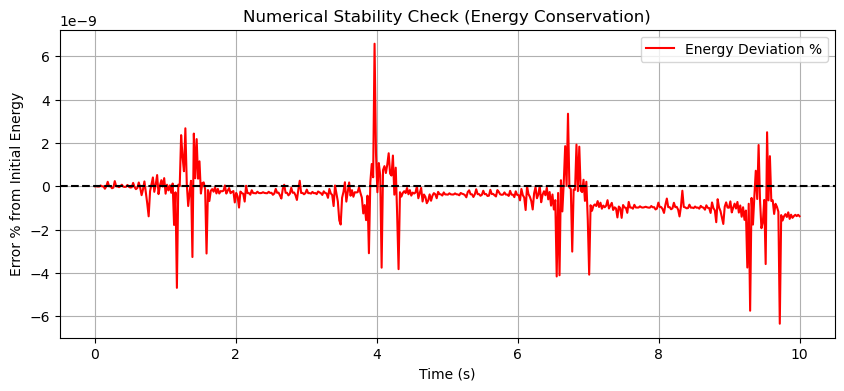

In [8]:
# Example usage:
verify_pendulum_data(filename, M=1.0, m=0.1, l=1.0, g=9.81)

Note: If you were to see a "staircase" or a "ramp" in the error plot, it would mean the simulation is gaining or losing energy due to numerical integration errors. Validating a controller against "leaky" physics can lead to a controller that is either overly aggressive (fighting phantom energy gain) or sluggish (ignoring phantom energy loss). Based on the current check, your data is perfectly reliable for control system validation.